# Diabetes Dataset CatBoost 회귀

## 개요
- scikit-learn `load_diabetes` 회귀 데이터셋으로 **질병 진행 정도(연속값)** 예측
- CatBoost Regressor로 성능 향상 및 하이퍼파라미터 최적화(GridSearchCV)
- 평가 지표: **R2**, **RMSE**

## 주요 단계
1. 데이터 로드 및 분리
2. CatBoost Regressor 설정
3. GridSearchCV 최적화
4. 성능 평가 및 피처 중요도 분석


In [3]:
!pip install catboost

## 라이브러리 임포트

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error


## 1. 데이터 로드

In [5]:
print("Loading Diabetes Regression Dataset...")
diabetes = load_diabetes(as_frame=True)

X = diabetes.data
y = diabetes.target

print(f"데이터 크기: {X.shape}")
print(f"타깃 크기: {y.shape}")
print(f"피처 목록: {list(X.columns)}")
print(f"타깃(연속값) 요약: min={y.min():.2f}, max={y.max():.2f}, mean={y.mean():.2f}")


Loading Diabetes Regression Dataset...
데이터 크기: (442, 10)
타깃 크기: (442,)
피처 목록: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
타깃(연속값) 요약: min=25.00, max=346.00, mean=152.13


**데이터 샘플 확인**

In [6]:
# 데이터 샘플
print("\n데이터 샘플:")
display(X.head())

print("\n기술 통계:")
display(X.describe())



데이터 샘플:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



기술 통계:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


**학습/테스트 데이터 분리**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (353, 10), Test: (89, 10)


## 2. CatBoost Regressor

**모델 설정**

In [8]:
# CatBoost Regressor
cat_reg = CatBoostRegressor(
    random_state=42,
    verbose=0  # 학습 과정 출력 억제
)

print("CatBoost Regressor 생성")
print("기본 설정: loss_function='RMSE', verbose=0")


CatBoost Regressor 생성
기본 설정: loss_function='RMSE', verbose=0


## 3. GridSearchCV 하이퍼파라미터 탐색

In [9]:
# 하이퍼파라미터 그리드
param_grid = {
    'iterations': [100, 200, 300],           # 트리 개수 (n_estimators와 동일)
    'learning_rate': [0.01, 0.05, 0.1],      # 학습률
    'depth': [4, 6, 8],                      # 트리 깊이
    'l2_leaf_reg': [1, 3, 5],                # L2 정규화
    'border_count': [32, 64]                 # 수치형 피처 분할 개수
}

print("파라미터 그리드:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\n총 조합 수: {total_combinations}개")


파라미터 그리드:
  iterations: [100, 200, 300]
  learning_rate: [0.01, 0.05, 0.1]
  depth: [4, 6, 8]
  l2_leaf_reg: [1, 3, 5]
  border_count: [32, 64]

총 조합 수: 162개


In [10]:
# GridSearchCV
print("\nTuning CatBoost Regressor...")
print("(교차검증 수행 중...)\n")

grid_reg = GridSearchCV(
    cat_reg,
    param_grid,
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_reg.fit(X_train, y_train)
print("\nGridSearchCV 완료!")



Tuning CatBoost Regressor...
(교차검증 수행 중...)

Fitting 5 folds for each of 162 candidates, totalling 810 fits

GridSearchCV 완료!


## 4. 최적화 결과 분석

In [11]:
# 최적 모델 추출
best_reg = grid_reg.best_estimator_

print("[최적화 결과]")
print(f"Best R2 Score (Train CV): {grid_reg.best_score_:.4f}")
print("\nBest Parameters:")
for param, value in grid_reg.best_params_.items():
    print(f"  {param}: {value}")


[최적화 결과]
Best R2 Score (Train CV): 0.4561

Best Parameters:
  border_count: 64
  depth: 4
  iterations: 100
  l2_leaf_reg: 5
  learning_rate: 0.1


**GridSearchCV 상위 결과**

In [12]:
# 상위 5개 결과
cv_results = pd.DataFrame(grid_reg.cv_results_)

# 보기 좋은 컬럼만 선택(존재하는 것만)
candidate_cols = [
    'param_iterations', 'param_learning_rate', 'param_depth',
    'param_l2_leaf_reg', 'param_border_count',
    'mean_test_score', 'std_test_score', 'rank_test_score'
]
cols = [c for c in candidate_cols if c in cv_results.columns]

top_results = cv_results.nsmallest(5, 'rank_test_score')[cols]

print("\n상위 5개 파라미터 조합:")
display(top_results)



상위 5개 파라미터 조합:


,param_iterations,param_learning_rate,param_depth,param_l2_leaf_reg,param_border_count,mean_test_score,std_test_score,rank_test_score
89,100,0.10,4,5,64,0.456112,0.025902,1
82,100,0.05,4,1,64,0.454463,0.027356,2
85,100,0.05,4,3,64,0.452963,0.029326,3
88,100,0.05,4,5,64,0.451607,0.027379,4
124,200,0.05,6,5,64,0.451289,0.023942,5


## 5. 테스트 데이터 평가

In [13]:
# 테스트 데이터 예측 및 평가
y_pred = best_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R2 Score: {r2:.4f}")


Test RMSE: 51.7362
Test R2 Score: 0.4948


## 6. 피처 중요도 분석

**CatBoost 내장 시각화**

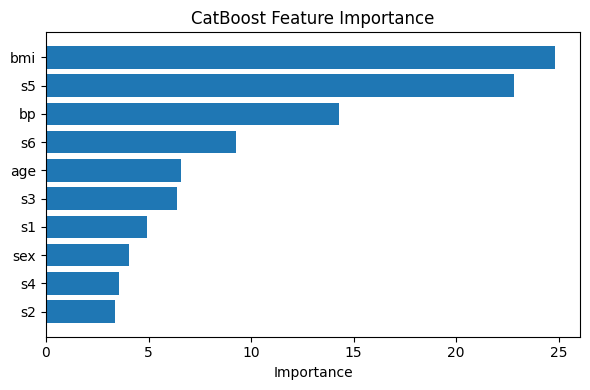

In [14]:
# CatBoost 피처 중요도 (PredictionValuesChange 방식)
feature_importance = best_reg.get_feature_importance()
feature_names = X.columns

# 데이터프레임 생성
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(6, 4))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('CatBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**수동 피처 중요도 추출 및 시각화**


피처 중요도 순위:


,Feature,Importance
0,bmi,24.794007
1,s5,22.816381
2,bp,14.282043
3,s6,9.265849
4,age,6.563289
5,s3,6.393275
6,s1,4.905103
7,sex,4.054540
8,s4,3.583497
9,s2,3.342015


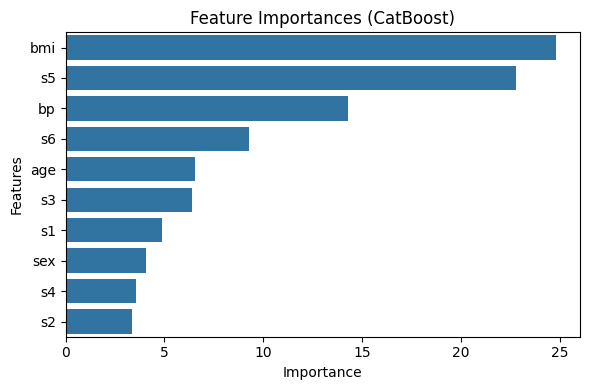

In [15]:
# 피처 중요도 추출
importances = best_reg.get_feature_importance()
feature_names = X.columns
indices = np.argsort(importances)[::-1]

importance_df = pd.DataFrame({
    'Feature': feature_names[indices],
    'Importance': importances[indices]
})

print("\n피처 중요도 순위:")
display(importance_df)

plt.figure(figsize=(6, 4))
sns.barplot(x=importance_df['Importance'], y=importance_df['Feature'])
plt.title("Feature Importances (CatBoost)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()
